<a href="https://colab.research.google.com/github/hamagami/hgliruca/blob/main/ssrpca20260408.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing japanize-matplotlib...
✅ Dependencies ready.
✅ Libraries loaded.
   yfinance version : 0.2.66
   Run time         : 2026-04-11 00:00:19
📅 Fetch period : 2020-04-12 → 2026-04-11
📐 λ=0.9, K=3, L=60, q=0.3
📡 Fetching market data …  (may take ~2 min for 28 tickers)
   ✓ 5/28 fetched
   ✓ 10/28 fetched
   ✓ 15/28 fetched
   ✓ 20/28 fetched
   ✓ 25/28 fetched
   ✓ 28/28 fetched

✅ Fetch complete.
   US: 11/11  |  JP: 17/17
   Period : 2020-04-13 → 2026-04-10
   Rows   : 1559
✅ Returns ready  cc:(1411, 28)  oc_jp:(1411, 17)
   CC  last date : 2026-04-10
   OC  last date : 2026-04-10
V0 shape: (28, 3)  |  orthogonality error: 3.33e-16
C0 built  |  diag mean: 1.0000
⏳ Computing PCA SUB signals …
✅ Signals: (1200, 17)  (2021-03-10 → 2026-04-11)
⏳ Computing PCA PLAIN signals …
✅ Baselines done.
Aligned dates: 1199

Strategy        AR(%)  Risk(%)    R/R   MDD(%)
MOM             -3.07    11.52  -0.27   -28.33
PCA PLAIN        5.49    10.95   0.50   -21.85
PCA SUB         13.92    11.28  

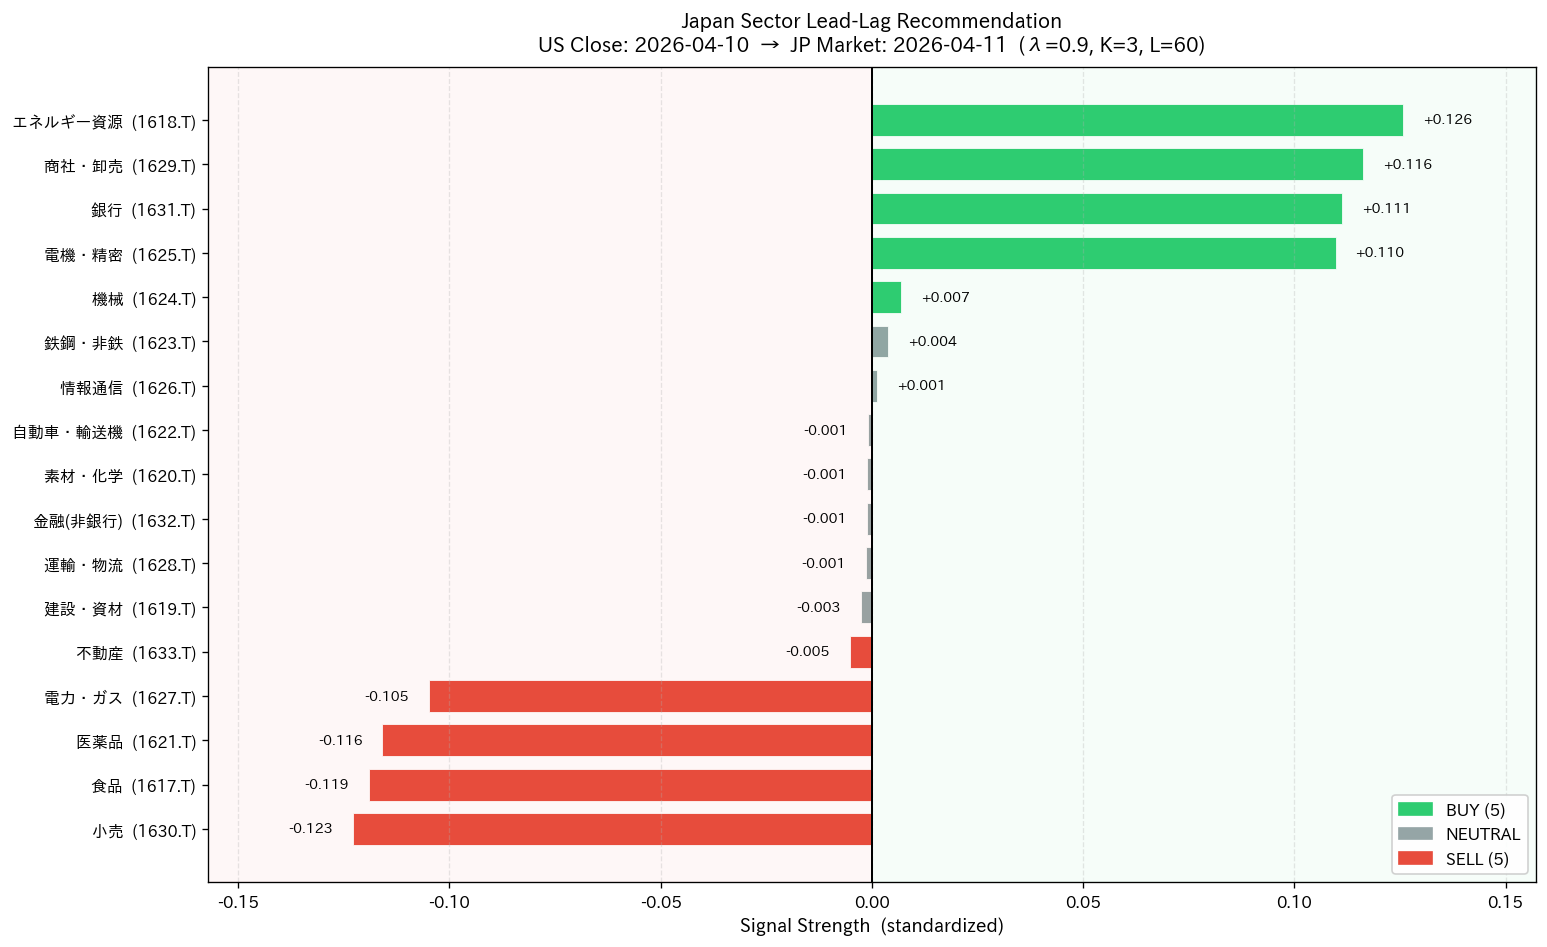

✅  Fig 1 saved.


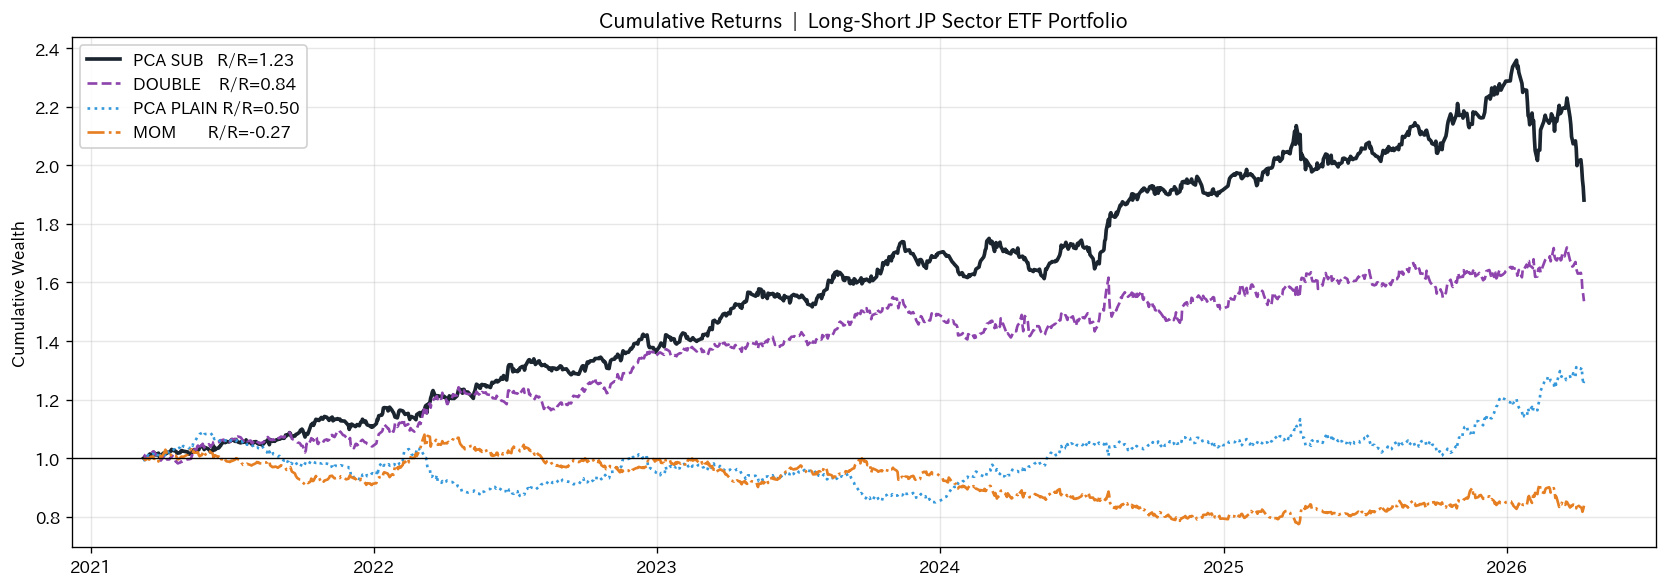

✅  Fig 2 saved.


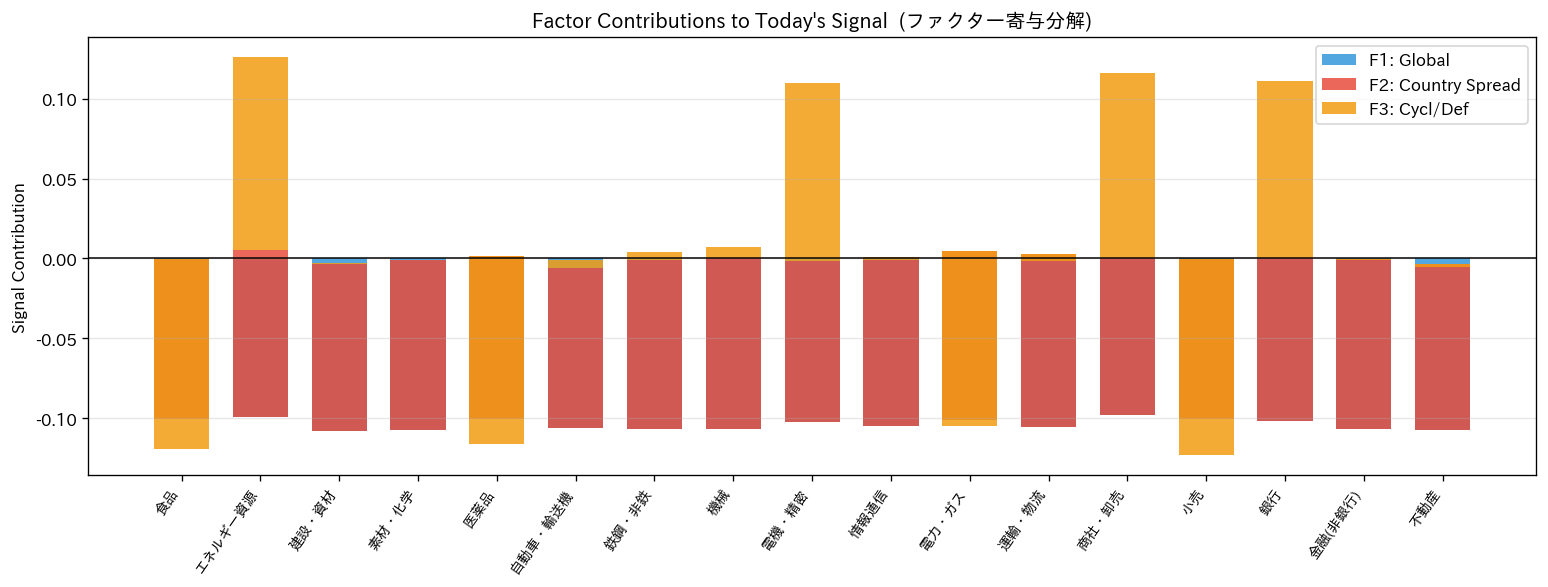

✅  Fig 3 saved.


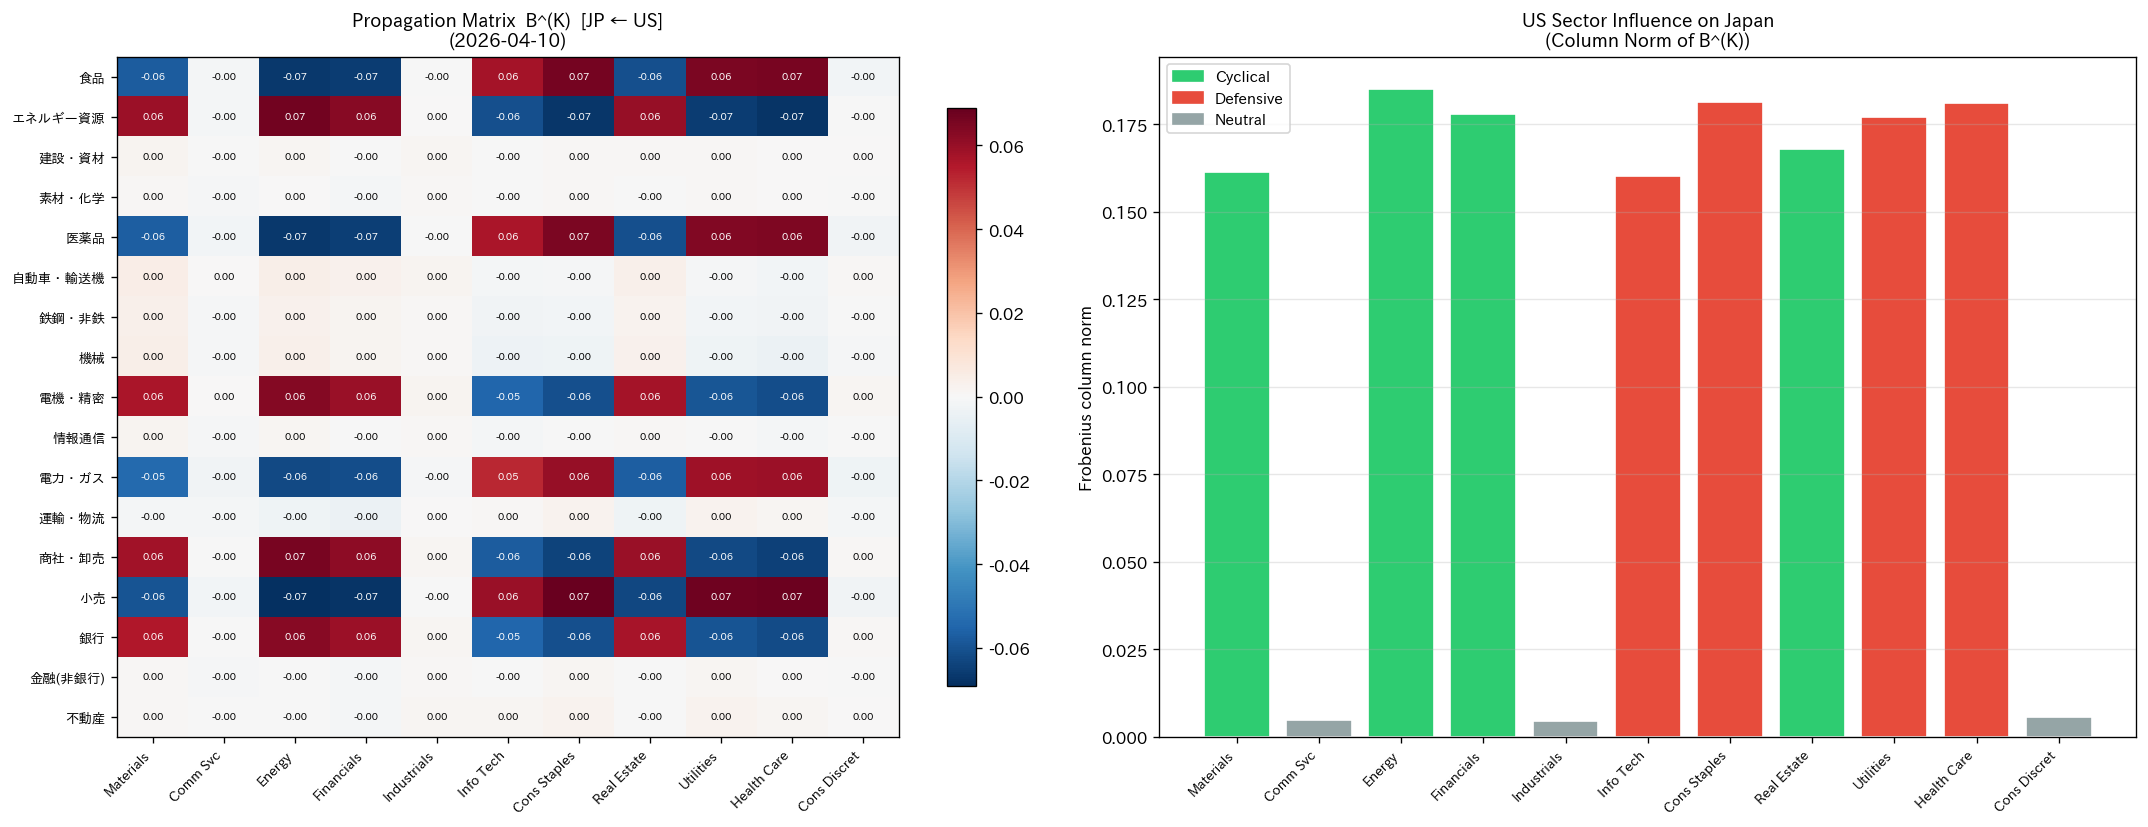

✅  Fig 4 saved.


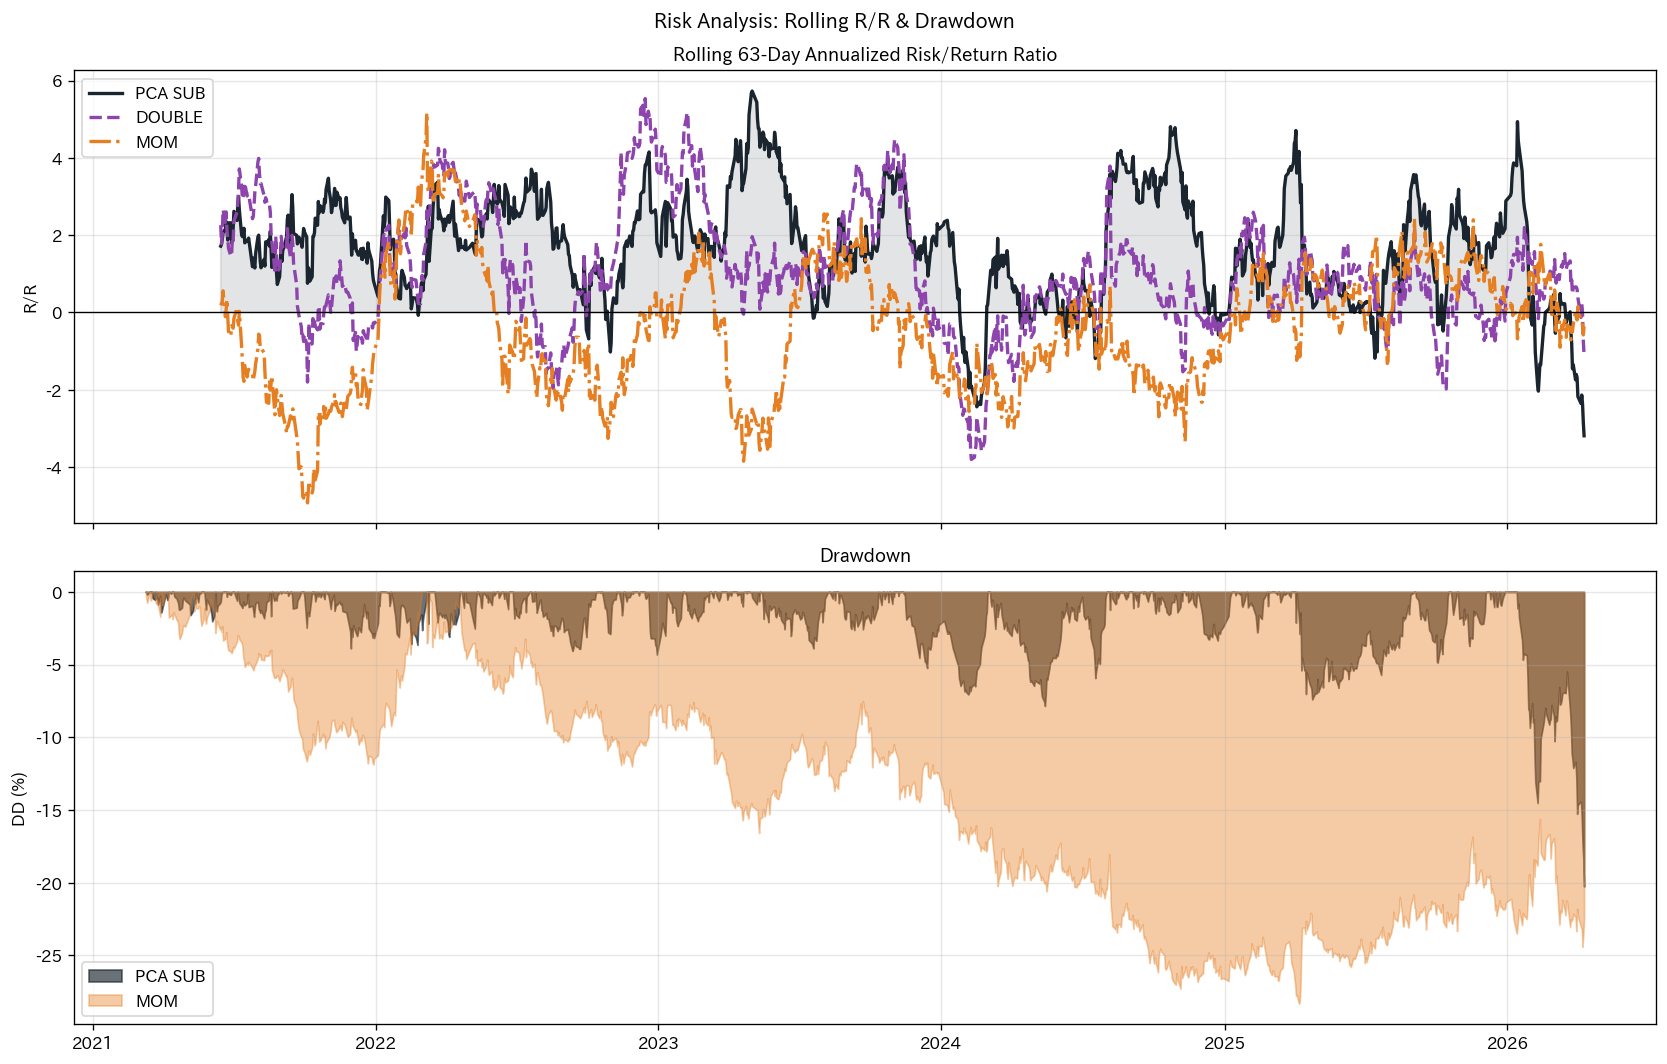

✅  Fig 5 saved.

  FINAL SUMMARY — Japan Sector Lead-Lag Strategy (PCA SUB)
  US data as of : 2026-04-10
  JP trade date : 2026-04-11

  Rank  Ticker     Sector                   Signal  Rec
  --------------------------------------------------------
  #1    1618.T     エネルギー資源                 +0.1258  🟢 BUY
  #2    1629.T     商社・卸売                   +0.1163  🟢 BUY
  #3    1631.T     銀行                      +0.1113  🟢 BUY
  #4    1625.T     電機・精密                   +0.1098  🟢 BUY
  #5    1624.T     機械                      +0.0069  🟢 BUY
  #6    1623.T     鉄鋼・非鉄                   +0.0037  ⚪ NEUTRAL
  #7    1626.T     情報通信                    +0.0012  ⚪ NEUTRAL
  #8    1622.T     自動車・輸送機                 -0.0010  ⚪ NEUTRAL
  #9    1620.T     素材・化学                   -0.0012  ⚪ NEUTRAL
  #10   1632.T     金融(非銀行)                 -0.0012  ⚪ NEUTRAL
  #11   1628.T     運輸・物流                   -0.0014  ⚪ NEUTRAL
  #12   1619.T     建設・資材                   -0.0027  ⚪ NEUTRAL
  #13   1633.T     不動産    

In [1]:
# ============================================================
# 日米業種リードラグ投資戦略（部分空間正則化付きPCA）
# Lead-Lag Strategy for Japanese and U.S. Sectors
# using Subspace Regularization PCA
#
# 論文: 中川慧・竹本悠城・久保健治・加藤真大 (2025)
#
# [Colab使用方法]
# ① このセルを実行: !pip install yfinance japanize-matplotlib --quiet
# ② ランタイム → 全てのセルを実行  (または Ctrl+F9)
# ============================================================

# %%
# ─── セル0: インストール（Colabのみ）───────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["yfinance", "japanize-matplotlib"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg}...")
        install(pkg)

print("✅ Dependencies ready.")

# %%
# ─── セル1: ライブラリ読み込み ──────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.linalg import eigh
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from datetime import datetime, timedelta
import yfinance as yf

try:
    import japanize_matplotlib
    HAS_JP_FONT = True
except ImportError:
    HAS_JP_FONT = False

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.unicode_minus": False,
    "font.size": 10,
})

print("✅ Libraries loaded.")
print(f"   yfinance version : {yf.__version__}")
print(f"   Run time         : {datetime.now():%Y-%m-%d %H:%M:%S}")

# %%
# ─── セル2: パラメータ設定 ──────────────────────────────────
WINDOW_L   = 60    # ローリングウィンドウ（営業日）
K_FACTORS  = 3     # 共通ファクター数
LAMBDA_REG = 0.9   # 正則化パラメータ λ
QUANTILE_Q = 0.30  # ロング/ショート分位点 q

TODAY      = datetime.today().strftime("%Y-%m-%d")
END_DATE   = TODAY
START_DATE = (datetime.today() - timedelta(days=365 * 6)).strftime("%Y-%m-%d")   # 6年

print(f"📅 Fetch period : {START_DATE} → {END_DATE}")
print(f"📐 λ={LAMBDA_REG}, K={K_FACTORS}, L={WINDOW_L}, q={QUANTILE_Q}")

# %%
# ─── セル3: ティッカー/名称定義 ─────────────────────────────
US_TICKERS = ["XLB","XLC","XLE","XLF","XLI","XLK",
               "XLP","XLRE","XLU","XLV","XLY"]

US_NAMES = {
    "XLB":"Materials", "XLC":"Comm Svc", "XLE":"Energy",
    "XLF":"Financials","XLI":"Industrials","XLK":"Info Tech",
    "XLP":"Cons Staples","XLRE":"Real Estate","XLU":"Utilities",
    "XLV":"Health Care","XLY":"Cons Discret",
}
US_CYCLICAL  = {"XLB","XLE","XLF","XLRE"}
US_DEFENSIVE = {"XLK","XLP","XLU","XLV"}

JP_TICKERS = ["1617.T","1618.T","1619.T","1620.T","1621.T","1622.T",
               "1623.T","1624.T","1625.T","1626.T","1627.T","1628.T",
               "1629.T","1630.T","1631.T","1632.T","1633.T"]

JP_NAMES = {
    "1617.T":"食品","1618.T":"エネルギー資源","1619.T":"建設・資材",
    "1620.T":"素材・化学","1621.T":"医薬品","1622.T":"自動車・輸送機",
    "1623.T":"鉄鋼・非鉄","1624.T":"機械","1625.T":"電機・精密",
    "1626.T":"情報通信","1627.T":"電力・ガス","1628.T":"運輸・物流",
    "1629.T":"商社・卸売","1630.T":"小売","1631.T":"銀行",
    "1632.T":"金融(非銀行)","1633.T":"不動産",
}
JP_CYCLICAL  = {"1618.T","1625.T","1629.T","1631.T"}
JP_DEFENSIVE = {"1617.T","1621.T","1627.T","1630.T"}

ALL_TICKERS = US_TICKERS + JP_TICKERS

# %%
# ─── セル4: データ取得（yfinance 最新API対応）──────────────
#
#  yfinance ≥0.2.x では download() が MultiIndex DataFrame を返す。
#  列構造: (field, ticker) の MultiIndex。
#  ここでは各ティッカーの Open / Close を個別に取得して結合する。
# ─────────────────────────────────────────────────────────────

def fetch_single(ticker: str, start: str, end: str) -> dict:
    """
    1ティッカーを取得して {'open': Series, 'close': Series} を返す。
    失敗時は None を返す。
    """
    try:
        raw = yf.download(
            ticker,
            start=start, end=end,
            auto_adjust=True,
            progress=False,
            threads=False,
        )
        if raw is None or raw.empty:
            return None

        # MultiIndex か flat か判定
        if isinstance(raw.columns, pd.MultiIndex):
            # (field, ticker) 形式
            level0 = raw.columns.get_level_values(0)
            if "Close" in level0:
                close = raw["Close"].iloc[:, 0]
            elif "Adj Close" in level0:
                close = raw["Adj Close"].iloc[:, 0]
            else:
                return None

            open_ = raw["Open"].iloc[:, 0] if "Open" in level0 else close.copy()
        else:
            # flat 形式
            if "Close" in raw.columns:
                close = raw["Close"]
            elif "Adj Close" in raw.columns:
                close = raw["Adj Close"]
            else:
                return None
            open_ = raw["Open"] if "Open" in raw.columns else close.copy()

        # インデックスのタイムゾーン除去
        for s in (close, open_):
            if hasattr(s.index, "tz") and s.index.tz is not None:
                s.index = s.index.tz_localize(None)

        close.name = ticker
        open_.name = ticker

        if len(close.dropna()) < 50:
            return None

        return {"open": open_, "close": close}

    except Exception as e:
        print(f"   ✗ {ticker}: {e}")
        return None


def fetch_ohlc(tickers: list, start: str, end: str) -> tuple:
    """全ティッカーを順次取得し open_df, close_df を返す。"""
    all_open, all_close, failed = {}, {}, []

    for i, t in enumerate(tickers):
        result = fetch_single(t, start, end)
        if result is None:
            failed.append(t)
            print(f"   ⚠ ({i+1}/{len(tickers)}) {t} — skipped")
        else:
            all_open[t]  = result["open"]
            all_close[t] = result["close"]
            if (i + 1) % 5 == 0 or (i + 1) == len(tickers):
                print(f"   ✓ {i+1}/{len(tickers)} fetched")

    open_df  = pd.DataFrame(all_open)
    close_df = pd.DataFrame(all_close)
    return open_df, close_df, failed


print("📡 Fetching market data …  (may take ~2 min for 28 tickers)")
open_df, close_df, failed_tickers = fetch_ohlc(ALL_TICKERS, START_DATE, END_DATE)

us_tickers = [t for t in US_TICKERS if t in close_df.columns]
jp_tickers = [t for t in JP_TICKERS if t in close_df.columns]
n_us = len(us_tickers)
n_jp = len(jp_tickers)

print(f"\n✅ Fetch complete.")
print(f"   US: {n_us}/{len(US_TICKERS)}  |  JP: {n_jp}/{len(JP_TICKERS)}")
if failed_tickers:
    print(f"   Failed : {failed_tickers}")
print(f"   Period : {close_df.index[0].date()} → {close_df.index[-1].date()}")
print(f"   Rows   : {len(close_df)}")

# %%
# ─── セル5: リターン計算 ─────────────────────────────────────
#
#  【修正】pct_change() の前に休場日（NaN行）を除去する。
#  除去しないと ffill → pct_change で休場日のリターンが 0.0 になり
#  インデックスが1日ずれる不具合が発生する。
#  例: 4/4(金)グッドフライデー休場 → NaN行が残り日付がずれる。
# ─────────────────────────────────────────────────────────────
ALL_T = us_tickers + jp_tickers

# ① US・JP いずれかに1銘柄でもNaNがある行（=休場日）を除去
close_clean = close_df[ALL_T].dropna(how="any")
open_clean  = open_df[ALL_T].dropna(how="any")

# ② Open/Close 両方で有効な日付のみ使用
idx_valid   = close_clean.index.intersection(open_clean.index)
close_clean = close_clean.loc[idx_valid]
open_clean  = open_clean.loc[idx_valid]

# ③ Close-to-Close リターン（PCA推定・モメンタム用）
cc = close_clean[ALL_T].pct_change().dropna()

# ④ Open-to-Close リターン（日本のみ・戦略評価用）
oc_jp = (close_clean[jp_tickers] / open_clean[jp_tickers] - 1).loc[cc.index]

print(f"✅ Returns ready  cc:{cc.shape}  oc_jp:{oc_jp.shape}")
print(f"   CC  last date : {cc.index[-1].date()}")
print(f"   OC  last date : {oc_jp.index[-1].date()}")

# %%
# ─── セル6: 部分空間正則化PCA 実装 ───────────────────────────
#   §3.1  事前固有ベクトル V0（グローバル / 国スプレッド / シクリカル）
#   §3.2  正則化相関行列 C_reg = (1-λ)Ct + λ C0
#   §3.3  シグナル: z_hat_J = V_J^(K) * V_U^(K)^T * z_U
# ─────────────────────────────────────────────────────────────

def gram_schmidt_orth(v_new: np.ndarray, basis: list) -> np.ndarray:
    for b in basis:
        v_new = v_new - np.dot(v_new, b) * b
    norm = np.linalg.norm(v_new)
    return v_new / norm if norm > 1e-12 else None


def build_prior_V0(us_t, jp_t, us_cyc, us_def, jp_cyc, jp_def) -> np.ndarray:
    n_us_l, n_jp_l = len(us_t), len(jp_t)
    N = n_us_l + n_jp_l

    # v1: グローバル
    v1 = np.ones(N) / np.sqrt(N)

    # v2: 国スプレッド（米+, 日-）
    raw2 = np.concatenate([np.ones(n_us_l), -np.ones(n_jp_l)])
    v2 = gram_schmidt_orth(raw2, [v1])

    # v3: シクリカル(+) / ディフェンシブ(-)
    raw3 = np.zeros(N)
    for i, t in enumerate(us_t):
        if t in us_cyc:  raw3[i]          = +1.0
        if t in us_def:  raw3[i]          = -1.0
    for j, t in enumerate(jp_t):
        if t in jp_cyc:  raw3[n_us_l + j] = +1.0
        if t in jp_def:  raw3[n_us_l + j] = -1.0
    v3 = gram_schmidt_orth(raw3, [v1, v2])
    if v3 is None:
        rng = np.random.default_rng(42)
        raw3 = rng.standard_normal(N)
        v3 = gram_schmidt_orth(raw3, [v1, v2])

    return np.column_stack([v1, v2, v3])   # (N, 3)


def build_C0(V0: np.ndarray, Z_long: np.ndarray) -> np.ndarray:
    """式(10)-(12): 事前エクスポージャー行列 C0"""
    C_full = np.corrcoef(Z_long.T)
    D0 = np.diag(np.diag(V0.T @ C_full @ V0))
    C0_raw = V0 @ D0 @ V0.T
    d = np.sqrt(np.maximum(np.diag(C0_raw), 1e-12))
    C0 = C0_raw / np.outer(d, d)
    np.fill_diagonal(C0, 1.0)
    return C0


def standardize(X: np.ndarray):
    mu    = X.mean(axis=0)
    sigma = np.where(X.std(axis=0) < 1e-10, 1e-10, X.std(axis=0))
    return (X - mu) / sigma, mu, sigma


def top_k_eigvecs(M: np.ndarray, k: int):
    """対称行列の上位k固有ベクトルを安定して取得"""
    vals, vecs = eigh(M)           # eigh: 対称行列専用・高速
    idx = np.argsort(vals)[::-1]   # 降順
    return vecs[:, idx[:k]]


def compute_signal_series(cc_df: pd.DataFrame,
                           V0: np.ndarray, C0: np.ndarray,
                           n_us: int, n_jp: int,
                           L: int = 60, K: int = 3,
                           lam: float = 0.9,
                           today_str: str = None):
    """
    全期間ローリングでシグナルを計算。
    t日のUSデータ → 翌営業日(t+1)のJP予測 として割り当て。
    最終行(dates[-1])も含めてループし、その翌日は today_str を使用。

    戻り値: signals_df  (date+1 x jp_tickers)
            ft_df       (date+1 x K)
    """
    dates    = cc_df.index
    jp_cols  = list(cc_df.columns[n_us:])
    sigs, fts = [], []

    # 【修正】len(dates)-1 → len(dates): 最終行も処理対象に含める
    for t in range(L, len(dates)):
        W = cc_df.iloc[t - L: t].values
        Z, mu, sigma = standardize(W)

        Ct  = np.corrcoef(Z.T)
        np.fill_diagonal(Ct, 1.0)
        np.clip(Ct, -1, 1, out=Ct)

        Ct_reg = (1 - lam) * Ct + lam * C0

        Vt_K  = top_k_eigvecs(Ct_reg, K)
        Vt_U  = Vt_K[:n_us]
        Vt_J  = Vt_K[n_us:]

        r_us  = cc_df.iloc[t, :n_us].values
        s_u   = np.where(sigma[:n_us] < 1e-10, 1e-10, sigma[:n_us])
        z_u   = (r_us - mu[:n_us]) / s_u

        ft      = Vt_U.T @ z_u
        z_hat_J = Vt_J @ ft

        sigs.append(z_hat_J)
        fts.append(ft)

    # 【修正】シグナル日付の割り当て
    # dates[t] のシグナル → 翌営業日 dates[t+1] に有効
    # 最終 t=dates[-1] の翌営業日 = 実行当日(TODAY)
    next_dates = list(dates[L + 1:])
    today_ts   = pd.Timestamp(today_str) if today_str else dates[-1] + pd.tseries.offsets.BDay(1)
    next_dates.append(today_ts)

    sig_dates = pd.DatetimeIndex(next_dates[:len(sigs)])
    sig_df = pd.DataFrame(sigs, index=sig_dates, columns=jp_cols)
    ft_df  = pd.DataFrame(fts,  index=sig_dates,
                           columns=[f"F{k+1}" for k in range(K)])
    return sig_df, ft_df


# ── 事前 V0, C0 を構築 ──
V0 = build_prior_V0(
    us_tickers, jp_tickers,
    US_CYCLICAL, US_DEFENSIVE,
    JP_CYCLICAL, JP_DEFENSIVE,
)
print(f"V0 shape: {V0.shape}  |  orthogonality error: "
      f"{np.max(np.abs(V0.T @ V0 - np.eye(3))):.2e}")

# 事前推定ウィンドウ（最初の60%を使用、最大3年）
prior_end = min(int(len(cc) * 0.6), 756)
Z_prior, _, _ = standardize(cc.iloc[:prior_end].values)
C0 = build_C0(V0, Z_prior)
print(f"C0 built  |  diag mean: {np.diag(C0).mean():.4f}")

# ── シグナル生成（直近5年分） ──
RECENT_ROWS = min(len(cc), 1260)   # 最大5年(252×5)
cc_recent   = cc.iloc[-RECENT_ROWS:]

print("⏳ Computing PCA SUB signals …")
sig_sub, ft_df = compute_signal_series(
    cc_recent, V0, C0, n_us, n_jp,
    L=WINDOW_L, K=K_FACTORS, lam=LAMBDA_REG, today_str=TODAY,
)
print(f"✅ Signals: {sig_sub.shape}  "
      f"({sig_sub.index[0].date()} → {sig_sub.index[-1].date()})")

# %%
# ─── セル7: ベースライン戦略 ─────────────────────────────────

# MOM: 日本のみのウィンドウ平均（式31）
mom_raw = cc_recent[jp_tickers].rolling(WINDOW_L).mean().shift(1)
sig_mom = mom_raw.dropna()

# PCA PLAIN: λ=0 の通常PCA
print("⏳ Computing PCA PLAIN signals …")
sig_plain, _ = compute_signal_series(
    cc_recent, V0, C0, n_us, n_jp,
    L=WINDOW_L, K=K_FACTORS, lam=0.0, today_str=TODAY,
)
print("✅ Baselines done.")

# 共通インデックスに整列
idx_all = sig_sub.index \
            .intersection(sig_mom.index) \
            .intersection(sig_plain.index) \
            .intersection(oc_jp.index)

sig_sub_a   = sig_sub.reindex(idx_all)[jp_tickers].fillna(0)
sig_mom_a   = sig_mom.reindex(idx_all)[jp_tickers].fillna(0)
sig_plain_a = sig_plain.reindex(idx_all)[jp_tickers].fillna(0)
oc_common   = oc_jp.reindex(idx_all)[jp_tickers].fillna(0)

print(f"Aligned dates: {len(idx_all)}")

# %%
# ─── セル8: L/S ポートフォリオ リターン計算 ──────────────────

def ls_returns(sig: pd.DataFrame, oc: pd.DataFrame, q: float = 0.30):
    """式(3)–(7): 等ウェイト L/S ポートフォリオ日次リターン"""
    n = sig.shape[1]
    n_pos = max(1, int(np.floor(n * q)))
    rets = []
    for date in sig.index:
        if date not in oc.index:
            rets.append(0.0); continue
        s = sig.loc[date]
        r = oc.loc[date]
        long_r  = r[s.nlargest(n_pos).index].mean()
        short_r = r[s.nsmallest(n_pos).index].mean()
        rets.append(long_r - short_r)
    return pd.Series(rets, index=sig.index)


def double_sort_returns(sig1: pd.DataFrame, sig2: pd.DataFrame,
                         oc: pd.DataFrame):
    """DOUBLE: 2×2 段ソート"""
    rets = []
    for date in sig1.index:
        if date not in oc.index or date not in sig2.index:
            rets.append(0.0); continue
        s1, s2, r = sig1.loc[date], sig2.loc[date], oc.loc[date]
        hi1 = s1 >= s1.median(); hi2 = s2 >= s2.median()
        long_set  = s1.index[hi1 & hi2]
        short_set = s1.index[~hi1 & ~hi2]
        if len(long_set) > 0 and len(short_set) > 0:
            rets.append(r[long_set].mean() - r[short_set].mean())
        else:
            rets.append(0.0)
    return pd.Series(rets, index=sig1.index)


ret_sub    = ls_returns(sig_sub_a,   oc_common, QUANTILE_Q)
ret_mom    = ls_returns(sig_mom_a,   oc_common, QUANTILE_Q)
ret_plain  = ls_returns(sig_plain_a, oc_common, QUANTILE_Q)
ret_double = double_sort_returns(sig_mom_a, sig_sub_a, oc_common)

# %%
# ─── セル9: パフォーマンス指標 ───────────────────────────────

def perf(r: pd.Series, ann: int = 252) -> dict:
    r = r.dropna()
    AR   = r.mean() * ann
    RISK = r.std()  * np.sqrt(ann)
    RR   = AR / RISK if RISK > 0 else 0
    cum  = (1 + r).cumprod()
    dd   = (cum / cum.cummax() - 1)
    MDD  = dd.min() * 100
    return dict(AR=AR*100, RISK=RISK*100, RR=RR, MDD=MDD)


metrics = {
    "MOM"      : perf(ret_mom),
    "PCA PLAIN": perf(ret_plain),
    "PCA SUB"  : perf(ret_sub),
    "DOUBLE"   : perf(ret_double),
}

print("\n" + "="*60)
print(f"{'Strategy':<12} {'AR(%)':>8} {'Risk(%)':>8} {'R/R':>6} {'MDD(%)':>8}")
print("="*60)
for name, m in metrics.items():
    marker = " ◀" if name == "PCA SUB" else ""
    print(f"{name:<12} {m['AR']:>8.2f} {m['RISK']:>8.2f} "
          f"{m['RR']:>6.2f} {m['MDD']:>8.2f}{marker}")
print("="*60)

# %%
# ─── セル10: 最新シグナル（本日推奨）────────────────────────

def latest_signal_with_decomp(cc_df, V0, C0, n_us, n_jp,
                               L=60, K=3, lam=0.9):
    """最新時点のシグナルとファクター寄与を計算"""
    t   = len(cc_df) - 1
    W   = cc_df.iloc[t - L: t].values
    Z, mu, sigma = standardize(W)

    Ct = np.corrcoef(Z.T)
    np.fill_diagonal(Ct, 1.0); np.clip(Ct, -1, 1, out=Ct)
    Ct_reg = (1 - lam) * Ct + lam * C0

    Vt_K = top_k_eigvecs(Ct_reg, K)
    Vt_U = Vt_K[:n_us]; Vt_J = Vt_K[n_us:]

    s_u  = np.where(sigma[:n_us] < 1e-10, 1e-10, sigma[:n_us])
    z_u  = (cc_df.iloc[t, :n_us].values - mu[:n_us]) / s_u
    ft   = Vt_U.T @ z_u

    contribs = {f"F{k+1}": Vt_J[:, k] * ft[k] for k in range(K)}
    return Vt_J @ ft, contribs, ft


us_date = cc_recent.index[-1]   # USの最新終値日
jp_date = pd.Timestamp(TODAY)   # 本日（JP推奨日）
z_today, contribs, ft_today = latest_signal_with_decomp(
    cc_recent, V0, C0, n_us, n_jp,
    L=WINDOW_L, K=K_FACTORS, lam=LAMBDA_REG,
)

# DataFrame 整形
rec_df = pd.DataFrame({
    "Sector" : [JP_NAMES[t] for t in jp_tickers],
    "Ticker" : jp_tickers,
    "Signal" : z_today,
}).set_index("Ticker")

max_abs = np.abs(z_today).max()
rec_df["NormScore"] = rec_df["Signal"] / max(max_abs, 1e-10)
rec_df["Rank"]      = rec_df["Signal"].rank(ascending=False).astype(int)
rec_df = rec_df.sort_values("Signal", ascending=False)

n_pos = max(1, int(np.floor(n_jp * QUANTILE_Q)))
long_t  = rec_df.head(n_pos).index.tolist()
short_t = rec_df.tail(n_pos).index.tolist()

def label(t):
    return "BUY" if t in long_t else "SELL" if t in short_t else "NEUTRAL"

rec_df["Rec"] = [label(t) for t in rec_df.index]

print(f"\n🎯  Signal base date (US close) : {us_date.date()}")
print(f"    Recommendation for JP market : {jp_date.date()}")
print(f"\n{'Rank':<5} {'Ticker':<10} {'Sector':<20} {'Signal':>8}  Rec")
print("-"*58)
for t, row in rec_df.iterrows():
    emoji = "🟢" if row.Rec=="BUY" else "🔴" if row.Rec=="SELL" else "⚪"
    print(f"#{row.Rank:<4} {t:<10} {row.Sector:<20} "
          f"{row.Signal:>+8.4f}  {emoji} {row.Rec}")

# %%
# ─── セル11: 可視化 ──────────────────────────────────────────
#
#  Figure 1 – 今日の推奨シグナル棒グラフ（買い→売り）
#  Figure 2 – 累積リターン推移
#  Figure 3 – ファクター寄与スタックバー
#  Figure 4 – 伝播行列ヒートマップ
#  Figure 5 – ローリング R/R & ドローダウン
# ─────────────────────────────────────────────────────────────

C_BUY  = "#2ECC71"
C_SELL = "#E74C3C"
C_NEU  = "#95A5A6"
C_SUB  = "#1A252F"
C_DBL  = "#8E44AD"
C_PLN  = "#3498DB"
C_MOM  = "#E67E22"

# ── Figure 1: 推奨シグナル（横棒）──────────────────────────
fig1, ax = plt.subplots(figsize=(13, 8))

disp = rec_df.sort_values("Signal")            # 下→上 = 売→買
colors_bar = [C_BUY if r=="BUY" else C_SELL if r=="SELL" else C_NEU
              for r in disp["Rec"]]
y_labels   = [f"{disp.loc[t,'Sector']}  ({t})" for t in disp.index]

bars = ax.barh(range(len(disp)), disp["Signal"],
               color=colors_bar, edgecolor="white", linewidth=0.5, height=0.72)

xl = max(np.abs(disp["Signal"].values)) * 1.25
ax.set_xlim(-xl, xl)

for i, (bar, val) in enumerate(zip(bars, disp["Signal"])):
    offset = xl * 0.03 * (1 if val >= 0 else -1)
    ha     = "left" if val >= 0 else "right"
    ax.text(val + offset, i, f"{val:+.3f}", va="center",
            ha=ha, fontsize=8.5, fontweight="bold")

ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(range(len(disp)))
ax.set_yticklabels(y_labels, fontsize=9.5)
ax.set_xlabel("Signal Strength  (standardized)", fontsize=11)
ax.set_title(
    f"Japan Sector Lead-Lag Recommendation\n"
    f"US Close: {us_date.date()}  →  JP Market: {jp_date.date()}  "
    f"(λ={LAMBDA_REG}, K={K_FACTORS}, L={WINDOW_L})",
    fontsize=12, fontweight="bold", pad=10,
)
ax.axvspan(0, xl,  alpha=0.04, color=C_BUY)
ax.axvspan(-xl, 0, alpha=0.04, color=C_SELL)
ax.grid(axis="x", alpha=0.3, linestyle="--")

ph = [mpatches.Patch(color=C_BUY,  label=f"BUY ({n_pos})"),
      mpatches.Patch(color=C_NEU,  label="NEUTRAL"),
      mpatches.Patch(color=C_SELL, label=f"SELL ({n_pos})")]
ax.legend(handles=ph, loc="lower right", fontsize=10, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig1_recommendation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Fig 1 saved.")

# ── Figure 2: 累積リターン ───────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(14, 5))

def cum(r): return (1 + r.dropna()).cumprod()

for r, lbl, col, ls in [
    (ret_sub,    f"PCA SUB   R/R={metrics['PCA SUB']['RR']:.2f}",
                 C_SUB,  "-"),
    (ret_double, f"DOUBLE    R/R={metrics['DOUBLE']['RR']:.2f}",
                 C_DBL, "--"),
    (ret_plain,  f"PCA PLAIN R/R={metrics['PCA PLAIN']['RR']:.2f}",
                 C_PLN, ":"),
    (ret_mom,    f"MOM       R/R={metrics['MOM']['RR']:.2f}",
                 C_MOM, "-."),
]:
    c = cum(r)
    ax2.plot(c.index, c.values, label=lbl, color=col,
             lw=2.2 if lbl.startswith("PCA SUB") else 1.6, ls=ls)

ax2.axhline(1, color="black", lw=0.8)
ax2.set_title("Cumulative Returns  |  Long-Short JP Sector ETF Portfolio",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Cumulative Wealth")
ax2.legend(fontsize=10, loc="upper left", framealpha=0.9)
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig2_cumreturns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Fig 2 saved.")

# ── Figure 3: ファクター寄与 ─────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(13, 5))

F_COLORS = ["#3498DB", "#E74C3C", "#F39C12"]
F_LABELS = ["F1: Global", "F2: Country Spread", "F3: Cycl/Def"]
bottom   = np.zeros(n_jp)
x_pos    = np.arange(n_jp)

for k, (fname, fcolor, flabel) in enumerate(
        zip(contribs, F_COLORS, F_LABELS)):
    vals = contribs[fname]
    ax3.bar(x_pos, vals, bottom=bottom, color=fcolor,
            label=flabel, alpha=0.85, width=0.7)
    bottom += vals

ax3.axhline(0, color="black", lw=0.9)
ax3.set_xticks(x_pos)
ax3.set_xticklabels([JP_NAMES[t] for t in jp_tickers],
                     rotation=55, ha="right", fontsize=8.5)
ax3.set_title("Factor Contributions to Today's Signal  (ファクター寄与分解)",
              fontsize=12, fontweight="bold")
ax3.set_ylabel("Signal Contribution")
ax3.legend(fontsize=10)
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig3_factor_contrib.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Fig 3 saved.")

# ── Figure 4: 伝播行列ヒートマップ ──────────────────────────
def get_prop_matrix(cc_df, V0, C0, n_us, n_jp, L, K, lam):
    t  = len(cc_df) - 1
    W  = cc_df.iloc[t - L: t].values
    Z, _, _ = standardize(W)
    Ct  = np.corrcoef(Z.T); np.fill_diagonal(Ct,1.0); np.clip(Ct,-1,1,out=Ct)
    Cr  = (1-lam)*Ct + lam*C0
    Vt  = top_k_eigvecs(Cr, K)
    return Vt[n_us:] @ Vt[:n_us].T    # (n_jp, n_us)

Bt = get_prop_matrix(cc_recent, V0, C0, n_us, n_jp, WINDOW_L, K_FACTORS, LAMBDA_REG)

fig4, axes4 = plt.subplots(1, 2, figsize=(18, 7))

lim = np.abs(Bt).max()
im  = axes4[0].imshow(Bt, cmap="RdBu_r", aspect="auto",
                       vmin=-lim, vmax=lim)
axes4[0].set_xticks(range(n_us))
axes4[0].set_xticklabels([US_NAMES.get(t,t) for t in us_tickers],
                           rotation=45, ha="right", fontsize=8)
axes4[0].set_yticks(range(n_jp))
axes4[0].set_yticklabels([JP_NAMES.get(t,t) for t in jp_tickers], fontsize=8)
axes4[0].set_title(f"Propagation Matrix  B^(K)  [JP ← US]\n({us_date.date()})",
                    fontsize=11, fontweight="bold")
plt.colorbar(im, ax=axes4[0], shrink=0.85)
for i in range(n_jp):
    for j in range(n_us):
        fc = "white" if abs(Bt[i,j]) > 0.3*lim else "black"
        axes4[0].text(j, i, f"{Bt[i,j]:.2f}",
                      ha="center", va="center", fontsize=6, color=fc)

# 列ノルム（米国セクターの影響力）
col_norms = np.linalg.norm(Bt, axis=0)
bc = [C_BUY if t in US_CYCLICAL else
      C_SELL if t in US_DEFENSIVE else C_NEU
      for t in us_tickers]
axes4[1].bar(range(n_us), col_norms, color=bc, edgecolor="white")
axes4[1].set_xticks(range(n_us))
axes4[1].set_xticklabels([US_NAMES.get(t,t) for t in us_tickers],
                           rotation=45, ha="right", fontsize=8)
axes4[1].set_title("US Sector Influence on Japan\n(Column Norm of B^(K))",
                    fontsize=11, fontweight="bold")
axes4[1].set_ylabel("Frobenius column norm")
axes4[1].grid(axis="y", alpha=0.3)
leg4 = [mpatches.Patch(color=C_BUY,  label="Cyclical"),
        mpatches.Patch(color=C_SELL, label="Defensive"),
        mpatches.Patch(color=C_NEU,  label="Neutral")]
axes4[1].legend(handles=leg4, fontsize=9)
plt.tight_layout()
plt.savefig("fig4_propagation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Fig 4 saved.")

# ── Figure 5: ローリング R/R & ドローダウン ──────────────────
def rolling_rr(r: pd.Series, w: int = 63, ann: int = 252):
    out = []
    for i in range(w, len(r)):
        sub  = r.iloc[i-w:i]
        ar   = sub.mean() * ann
        risk = sub.std()  * np.sqrt(ann)
        out.append(ar/risk if risk > 0 else 0)
    return pd.Series(out, index=r.index[w:])

def drawdown(r: pd.Series):
    c = (1+r).cumprod()
    return (c/c.cummax()-1)*100

fig5, (ax5a, ax5b) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# R/R
for r, lbl, col, ls in [
    (ret_sub,    "PCA SUB",    C_SUB, "-"),
    (ret_double, "DOUBLE",     C_DBL, "--"),
    (ret_mom,    "MOM",        C_MOM, "-."),
]:
    rr = rolling_rr(r, w=63)
    ax5a.plot(rr.index, rr.values, label=lbl, color=col, lw=2.0, ls=ls)
ax5a.axhline(0, color="black", lw=0.8)
rr_sub = rolling_rr(ret_sub, 63)
ax5a.fill_between(rr_sub.index, 0, rr_sub.values,
                   where=rr_sub.values > 0,
                   alpha=0.12, color=C_SUB)
ax5a.set_title("Rolling 63-Day Annualized Risk/Return Ratio", fontsize=11, fontweight="bold")
ax5a.set_ylabel("R/R"); ax5a.legend(fontsize=10); ax5a.grid(alpha=0.3)

# ドローダウン
for r, lbl, col, al in [
    (ret_sub,  "PCA SUB", C_SUB, 0.65),
    (ret_mom,  "MOM",     C_MOM, 0.40),
]:
    dd = drawdown(r)
    ax5b.fill_between(dd.index, 0, dd.values, alpha=al, color=col, label=lbl)
ax5b.set_title("Drawdown", fontsize=11, fontweight="bold")
ax5b.set_ylabel("DD (%)"); ax5b.legend(fontsize=10); ax5b.grid(alpha=0.3)

fig5.suptitle("Risk Analysis: Rolling R/R & Drawdown", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig5_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅  Fig 5 saved.")

# %%
# ─── セル12: 最終サマリー ────────────────────────────────────
print("\n" + "="*68)
print("  FINAL SUMMARY — Japan Sector Lead-Lag Strategy (PCA SUB)")
print("="*68)
print(f"  US data as of : {us_date.date()}")
print(f"  JP trade date : {jp_date.date()}")
print()
print(f"  {'Rank':<5} {'Ticker':<10} {'Sector':<22} {'Signal':>8}  Rec")
print("  " + "-"*56)
for t, row in rec_df.iterrows():
    e = "🟢" if row.Rec=="BUY" else "🔴" if row.Rec=="SELL" else "⚪"
    print(f"  #{row.Rank:<4} {t:<10} {row.Sector:<22} "
          f"{row.Signal:>+8.4f}  {e} {row.Rec}")
print()
print(f"  {'Strategy':<12}  {'AR':>7}  {'Risk':>7}  {'R/R':>6}  {'MDD':>8}")
print("  " + "-"*50)
for name, m in metrics.items():
    mk = " ◀" if name=="PCA SUB" else ""
    print(f"  {name:<12}  {m['AR']:>6.2f}%  {m['RISK']:>6.2f}%  "
          f"{m['RR']:>6.2f}  {m['MDD']:>7.2f}%{mk}")
print()
print("  Output: fig1_recommendation.png  fig2_cumreturns.png")
print("          fig3_factor_contrib.png   fig4_propagation.png  fig5_risk.png")
print("="*68)
print("  ⚠  Research only. Not financial advice.")
print("="*68)
